In [4]:
!pip install -q "git+https://github.com/facebookresearch/segment-anything.git"
!pip install -q groundingdino-py
!pip install -q rembg onnxruntime

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 10.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not curren

In [7]:
import torch
import segment_anything
import groundingdino

print("✅ PyTorch:", torch.__version__)
print("✅ Segment Anything imported successfully")
print("✅ GroundingDINO imported successfully")

ImportError: cannot import name '_Ink' from 'PIL._typing' (/usr/local/lib/python3.12/dist-packages/PIL/_typing.py)

In [8]:
!pip uninstall -y pillow
!pip install pillow==10.4.0

Found existing installation: pillow 12.3.0
Uninstalling pillow-12.3.0:
  Successfully uninstalled pillow-12.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 71.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rembg 2.0.77 requires pillow<13.0.0,>=12.1.0, but you have pillow 10.4.0 which is incompatible.
cucim-cu12 26.2.0 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.


In [1]:
import torch
import segment_anything

print("PyTorch:", torch.__version__)
print("Segment Anything imported successfully!")

PyTorch: 2.11.0+cu128
Segment Anything imported successfully!


In [2]:
!wget -O sam_vit_h_4b8939.pth \
https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

--2026-07-26 10:17:33--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 52.222.236.115, 52.222.236.65, 52.222.236.117, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|52.222.236.115|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   195MB/s    in 16s     

2026-07-26 10:17:49 (155 MB/s) - ‘sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



In [3]:
from segment_anything import sam_model_registry

sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
sam.to("cuda")

print("✅ SAM model loaded successfully!")

✅ SAM model loaded successfully!


In [4]:
from google.colab import files

uploaded = files.upload()

Saving person_01.png to person_01.png


Number of masks: 15


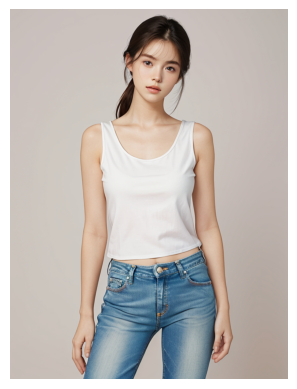

In [7]:
import cv2
import matplotlib.pyplot as plt
from segment_anything import SamAutomaticMaskGenerator

image = cv2.imread("person_01.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask_generator = SamAutomaticMaskGenerator(sam)
masks = mask_generator.generate(image)

print("Number of masks:", len(masks))

plt.imshow(image)
plt.axis("off")
plt.show()

In [8]:
!pip install -q transformers timm

In [9]:
from transformers import AutoImageProcessor, SegformerForSemanticSegmentation
import torch

processor = AutoImageProcessor.from_pretrained("matei-dorian/segformer-b5-finetuned-human-parsing")
model = SegformerForSemanticSegmentation.from_pretrained(
    "matei-dorian/segformer-b5-finetuned-human-parsing"
).to("cuda")

print("✅ Human Parsing Model Loaded")

preprocessor_config.json:   0%|          | 0.00/428 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.73k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  339MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

✅ Human Parsing Model Loaded


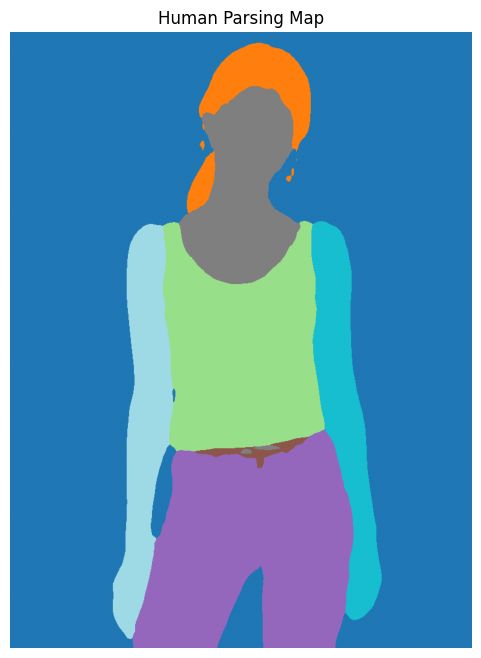

In [11]:
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Load your uploaded image
image = Image.open("person_01.png").convert("RGB")

# Process image
inputs = processor(images=image, return_tensors="pt").to("cuda")

# Inference
with torch.no_grad():
    outputs = model(**inputs)

# Convert prediction to parsing map
parsing = processor.post_process_semantic_segmentation(
    outputs,
    target_sizes=[image.size[::-1]]
)[0]

# Display parsing map
plt.figure(figsize=(6,8))
plt.imshow(parsing.cpu().numpy(), cmap="tab20")
plt.axis("off")
plt.title("Human Parsing Map")
plt.show()

In [12]:
plt.imsave(
    "human_parsing_map.png",
    parsing.cpu().numpy(),
    cmap="tab20"
)

print("✅ Parsing map saved!")

✅ Parsing map saved!


In [13]:
from google.colab import files

uploaded = files.upload()

Saving garment_01.jpg to garment_01.jpg


In [14]:
from rembg import remove
from PIL import Image

input_image = Image.open("garment_01.jpg")
output_image = remove(input_image)

output_image.save("garment_mask.png")

print("✅ Garment mask saved successfully!")

  0%|                                               | 0.00/176M [00:00<?, ?B/s]

✅ Garment mask saved successfully!


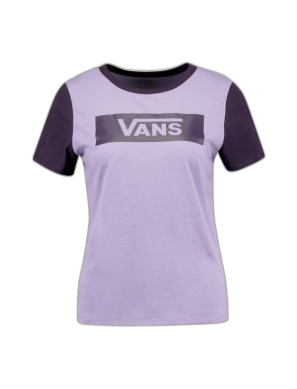

In [15]:
import matplotlib.pyplot as plt

plt.imshow(output_image)
plt.axis("off")
plt.show()

✅ Agnostic image saved!


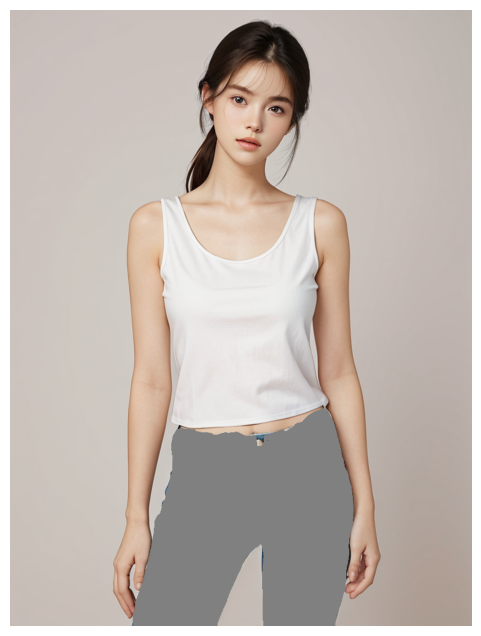

In [16]:
import numpy as np
from PIL import Image

# Original image
original = np.array(image)

# Parsing result
parsing_map = parsing.cpu().numpy()

# Copy image
agnostic = original.copy()

# Mask upper-body clothing classes
# (These class IDs may vary by model; adjust later if needed.)
upper_body_classes = [5, 6, 7]

for cls in upper_body_classes:
    agnostic[parsing_map == cls] = [128, 128, 128]

# Save and display
agnostic_image = Image.fromarray(agnostic)
agnostic_image.save("agnostic_person.png")

print("✅ Agnostic image saved!")

import matplotlib.pyplot as plt
plt.figure(figsize=(6,8))
plt.imshow(agnostic_image)
plt.axis("off")
plt.show()

In [17]:
import numpy as np

print("Unique classes in parsing map:")
print(np.unique(parsing.cpu().numpy()))

Unique classes in parsing map:
[ 0  2  4  6  8 11 14 15]


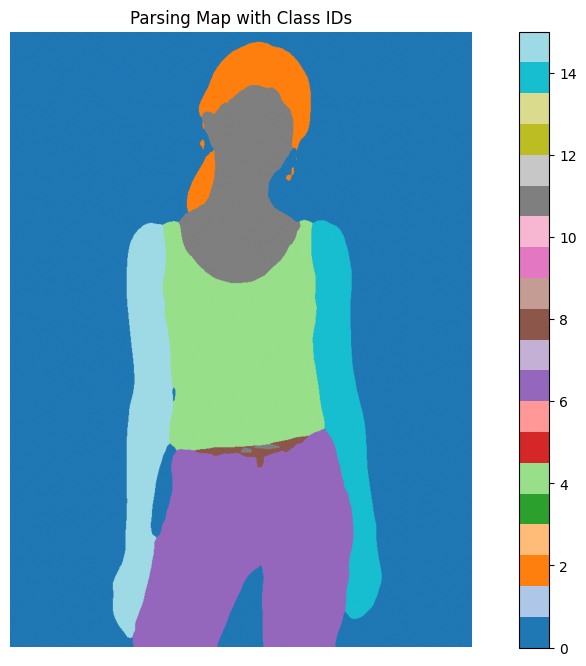

In [18]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,8))
plt.imshow(parsing.cpu().numpy(), cmap="tab20")
plt.colorbar()
plt.title("Parsing Map with Class IDs")
plt.axis("off")
plt.show()

✅ Agnostic image saved!


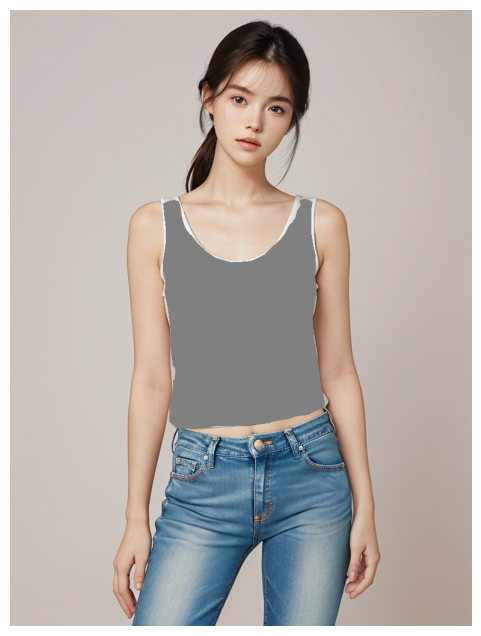

In [19]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

original = np.array(image)
parsing_map = parsing.cpu().numpy()

agnostic = original.copy()

# Mask only the shirt
agnostic[parsing_map == 4] = [128, 128, 128]

agnostic_image = Image.fromarray(agnostic)
agnostic_image.save("agnostic_person.png")

print("✅ Agnostic image saved!")

plt.figure(figsize=(6,8))
plt.imshow(agnostic_image)
plt.axis("off")
plt.show()